# Analysis -- degree-corrected SBM (complex network)

Reads `results_dp_sbm_dcsbm_n500.csv` from `script_dcsbm_synthetic_graph.py`.

n = 500, K = 2, nominal p = 0.2 / q = 0.02, with degree correction
`theta_u = |Z_u| + 1 - (2*pi)^(-1/2)`, `Z_u ~ N(0, 0.25)`. Dense (mean degree
~55), so graphs are connected and no LCC extraction is done.

Two things specific to this notebook:

* **`beta_nominal_*` vs `beta_true_*`.** The nominal p, q are the generative
  constants; `beta_true_*` is the empirical block density of each drawn
  graph, which is what a plain-SBM estimator actually targets. With
  `NORMALIZE_WEIGHTS = True` they agree to ~0.007%; the figures score against
  the empirical values and the gap is reported below.
* **Degree heterogeneity is the point of this experiment**, so the diagnostic
  for whether `edge_flip_spectral` is measuring regularization rather than
  privacy is especially relevant -- spectral clustering is well known to be
  pulled around by degree skew.


In [2]:
# -- load results (handles both single-file and sharded output) --------------
import glob
import numpy as np
import pandas as pd

OUTPUT_CSV = "./results/results_dp_sbm_dcsbm_n500.csv"   # match OUTPUT_CSV in the driver

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

_bad = df.loc[df["epsilon"] > 700, "sigma"].unique()
assert len(_bad) == 0, f"epsilon > 700 at sigma={_bad}: exp() overflowed in edge_flip"

FACET = None          # the sweep axis besides sigma (None = single panel)
FACETS = sorted(df[FACET].unique()) if FACET else [None]

print()
print("  sigma :", sorted(df["sigma"].unique()))
print("  method:", sorted(df["method"].unique()))
if FACET:
    print(f"  {FACET}:", FACETS)
print("  reps  :", sorted(df.groupby([c for c in ([FACET] if FACET else []) + ["sigma", "method"]]).size().unique()))
df.head()

Loaded ./results/results_dp_sbm_dcsbm_n500.csv, 300 rows.

  sigma : [1.0, 2.0, 5.0, 10.0, 20.0]
  method: ['edge_flip_spectral', 'edge_flip_vem', 'sbm_dpsgd_all_noised']
  reps  : [20]


,N,K,dc_sigma,normalize_weights,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,...,beta_nominal_00,beta_nominal_01,beta_nominal_11,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,nmi
0,500,2,0.25,True,1.0,27.438851,0,edge_flip_vem,NaN,NaN,...,0.2,0.02,0.2,0.19412,0.0192,0.201639,0.194120,0.019200,0.201639,1.000000
1,500,2,0.25,True,1.0,27.438851,0,edge_flip_spectral,NaN,NaN,...,0.2,0.02,0.2,0.19412,0.0192,0.201639,0.194120,0.019200,0.201639,1.000000
2,500,2,0.25,True,1.0,27.438851,0,sbm_dpsgd_all_noised,26.32774,5.635918,...,0.2,0.02,0.2,0.19412,0.0192,0.201639,0.217222,0.012015,0.216347,0.981183
3,500,2,0.25,True,2.0,11.728685,0,edge_flip_vem,NaN,NaN,...,0.2,0.02,0.2,0.19412,0.0192,0.201639,0.194083,0.019192,0.201634,1.000000
4,500,2,0.25,True,2.0,11.728685,0,edge_flip_spectral,NaN,NaN,...,0.2,0.02,0.2,0.19412,0.0192,0.201639,0.194083,0.019192,0.201634,1.000000


## Coverage


In [3]:
# -- which cells are complete? ------------------------------------------------
keys = ([FACET] if FACET else []) + ["sigma", "method"]
counts = df.groupby(keys).size().unstack("method").fillna(0).astype(int)
expected = int(counts.values.max()) if counts.size else 0
print(f"expected reps per cell (max seen): {expected}\n")
print(counts.to_string())
missing = counts[(counts < expected).any(axis=1)]
print("\nINCOMPLETE cells:\n" + missing.to_string() if len(missing) else "\nAll cells complete.")

# epochs is written for edge_flip_vem and sbm_dpsgd only -- spectral has no
# iterative epoch to count, so its blank column is expected, not a gap.
print("\nnon-null `epochs` by method:")
print(df.groupby("method")["epochs"].apply(lambda s: f"{s.notna().sum()}/{len(s)}").to_string())

print("\ndistinct epsilon per sigma (must all be 1):")
print(df.groupby("sigma")["epsilon"].nunique().to_string())

expected reps per cell (max seen): 20

method  edge_flip_spectral  edge_flip_vem  sbm_dpsgd_all_noised
sigma                                                          
1.0                     20             20                    20
2.0                     20             20                    20
5.0                     20             20                    20
10.0                    20             20                    20
20.0                    20             20                    20

All cells complete.

non-null `epochs` by method:
method
edge_flip_spectral        0/100
edge_flip_vem           100/100
sbm_dpsgd_all_noised    100/100

distinct epsilon per sigma (must all be 1):
sigma
1.0     1
2.0     1
5.0     1
10.0    1
20.0    1


## NMI


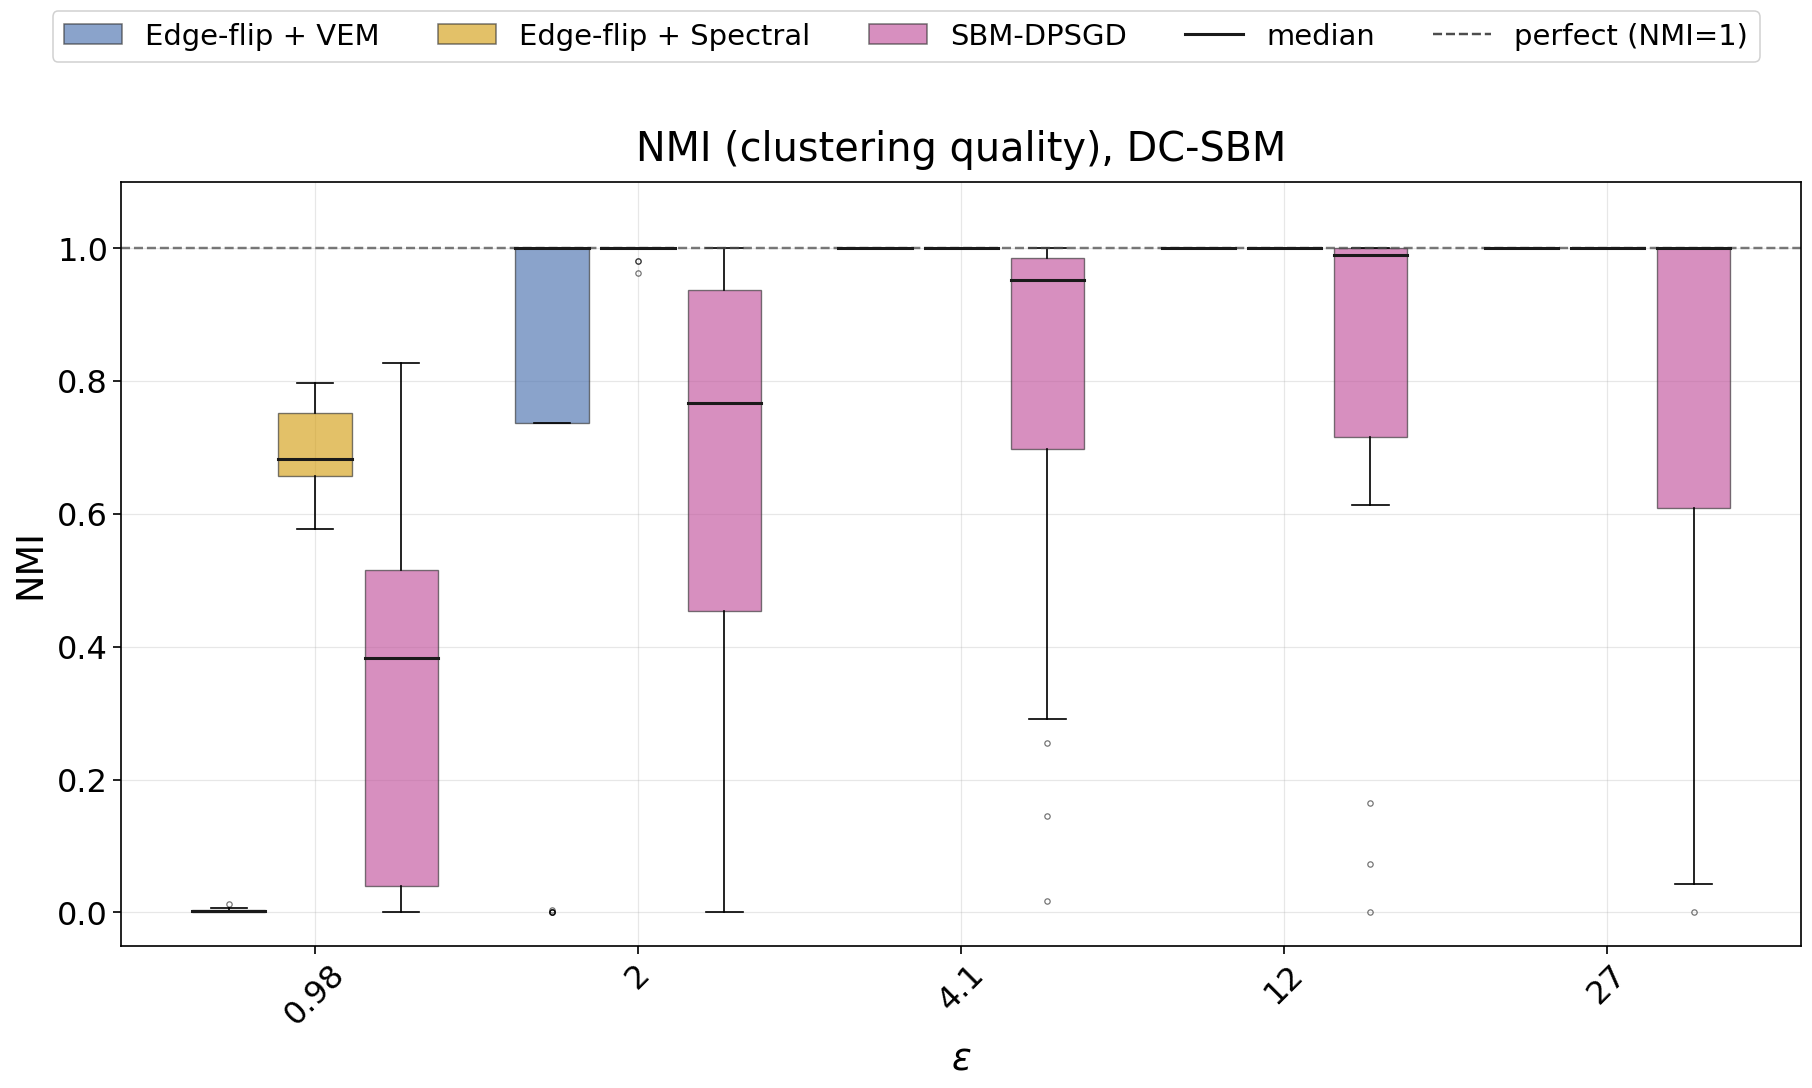

In [11]:
# -- Boxplot of NMI vs epsilon -----------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()
methods = order_methods(df["method"].unique())
sub = df.dropna(subset=["nmi"])

NMI_RC = {"font.size": 20, "axes.labelsize": 24, "xtick.labelsize": 21,
          "ytick.labelsize": 21, "legend.fontsize": 20}
with plt.rc_context(NMI_RC):
    fig, ax = plt.subplots(figsize=figsize(12.5, 7.5))
    grouped_boxplot(ax, sub, "nmi", methods=methods)
    reference_line(ax, 1.0)
    ax.set_ylim(-0.05, 1.1)
    ax.set_title('NMI (clustering quality), DC-SBM', fontsize=26, pad=14)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel("NMI", fontsize=24)
    handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                     label=method_label(m)) for m in methods]
    handles += [Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
                Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
                       label="perfect (NMI=1)")]
    fig.legend(handles=handles, loc="upper center", ncol=len(handles),
               fontsize=19, frameon=True, bbox_to_anchor=(0.5, 1.0))
    fig.tight_layout(rect=[0, 0, 1, 0.91])
    fig.savefig('figures/nmi_dcsbm_n500.png', dpi=200)
    plt.show()

### Per-rep spread


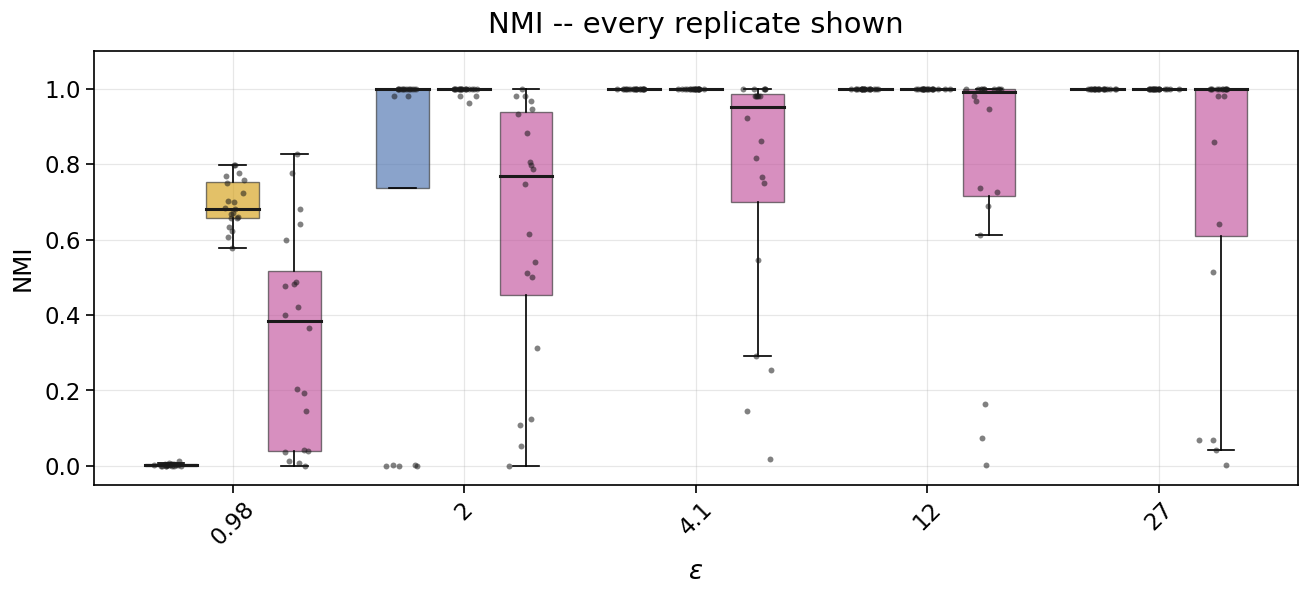

mean NMI  (collapse rate in brackets)

method edge_flip_spectral  edge_flip_vem sbm_dpsgd_all_noised
sigma                                                        
1.0            1.0  (0.0)     1.0  (0.0)         0.758  (0.2)
2.0            1.0  (0.0)     1.0  (0.0)         0.795  (0.1)
5.0            1.0  (0.0)     1.0  (0.0)         0.764  (0.1)
10.0         0.996  (0.0)  0.748  (0.25)          0.63  (0.2)
20.0         0.695  (0.0)   0.003  (1.0)        0.342  (0.35)

thresholds: {'edge_flip_vem': 0.2, 'edge_flip_spectral': 0.2, 'sbm_dpsgd_all_noised': 0.159}

BIMODAL cells -- means are not descriptive, use the scatter above:
  10.0  edge_flip_vem          mean=0.748  collapse=0.25
  1.0  sbm_dpsgd_all_noised   mean=0.758  collapse=0.20
  10.0  sbm_dpsgd_all_noised   mean=0.630  collapse=0.20
  20.0  sbm_dpsgd_all_noised   mean=0.342  collapse=0.35


In [5]:
# -- every rep, jittered over the box ----------------------------------------
from plot_style import box_positions

apply_style()
rng = np.random.default_rng(0)
eps_vals = sorted(df["epsilon"].unique())

fig, axes = plt.subplots(len(FACETS), 1,
                         figsize=figsize(9.0, 4.2 * len(FACETS)), squeeze=False)
for row, fv in enumerate(FACETS):
    ax = axes[row, 0]
    sub = (df if fv is None else df[df[FACET] == fv]).dropna(subset=["nmi"])
    grouped_boxplot(ax, sub, "nmi", methods=methods, showfliers=False)
    pos_map, width = box_positions(methods, eps_vals)
    for ev in eps_vals:
        for m in methods:
            v = sub.loc[(sub["epsilon"] == ev) & (sub["method"] == m), "nmi"].values
            if len(v) == 0:
                continue
            ax.scatter(pos_map[(ev, m)] + rng.normal(0, width * 0.12, len(v)), v,
                       s=15, color="#1A1A1A", alpha=0.55, zorder=4, linewidths=0)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(("NMI" if fv is None else f"{FACET} = {fv}\nNMI"), fontsize=16)
    if row == 0:
        ax.set_title("NMI -- every replicate shown", fontsize=19, pad=12)
plt.tight_layout()
plt.show()

# Collapse rate: fraction of reps below 20% of that method's OWN best cell mean.
# Relative, not absolute, because the achievable NMI differs hugely between
# these settings -- an absolute 0.15 cutoff would be meaningless in a regime
# where nothing exceeds 0.3.
keys = ([FACET] if FACET else []) + ["sigma"]
thresh = {m: 0.2 * df[df.method == m].groupby(keys)["nmi"].mean().max()
          for m in df["method"].unique()}
coll = (df.assign(fail=df.apply(lambda r: r["nmi"] < thresh[r["method"]], axis=1))
          .groupby(keys + ["method"])["fail"].mean().unstack("method").round(2))
mean_tbl = df.pivot_table(index=keys, columns="method", values="nmi", aggfunc="mean").round(3)
print("mean NMI  (collapse rate in brackets)\n")
print((mean_tbl.astype(str) + "  (" + coll.astype(str) + ")").to_string())
print("\nthresholds:", {k: round(v, 4) for k, v in thresh.items()})

flag = [(i, m) for m in coll.columns for i, v in coll[m].items()
        if v == v and 0.15 < v < 0.85]
if flag:
    print("\nBIMODAL cells -- means are not descriptive, use the scatter above:")
    for i, m in flag:
        print(f"  {i}  {m:<22} mean={mean_tbl.loc[i, m]:.3f}  collapse={coll.loc[i, m]:.2f}")
else:
    print("\nNo bimodal cells detected.")

## Is `edge_flip_spectral` measuring privacy?

Degree correction is precisely the condition under which plain spectral
clustering degenerates, so treat an interior optimum here as expected until
ruled out.


In [6]:
# -- IS edge_flip_spectral MEASURING PRIVACY, OR REGULARIZATION? --------------
# Established on polblogs: edge-flip adds p_flip*(N-1) random edges per node,
# which acts as the tau/N regularization that sparse / degree-heterogeneous
# spectral clustering needs (Amini et al. 2013; Qin & Rohe 2013).  That makes
# NMI a REGULARIZATION curve with an interior optimum, not a monotone privacy
# curve: too little noise leaves the degenerate cut in place, too much buries
# the signal.
#
# Signature to look for: edge_flip_spectral peaking at an INTERIOR epsilon
# rather than at the largest one.  If that happens here, the number at the
# peak is not "our DP method is good" -- it is "the DP noise happened to
# regularize a baseline that was broken without it".
#
# mean_degree here is of the drawn graph (pre-LCC where an LCC is taken), so
# tau_eff/mean_deg is approximate -- it is a diagnostic, not an estimate.
mdeg = df.groupby([c for c in ([FACET] if FACET else [])] + ["epsilon"])["mean_degree"].mean()

rows = []
for keyvals, g in df[df.method == "edge_flip_spectral"].groupby(
        [c for c in ([FACET] if FACET else [])] + ["epsilon"]):
    eps = keyvals[-1] if isinstance(keyvals, tuple) else keyvals
    p = 1.0 / (1.0 + np.exp(eps))
    n = int(g["n_fit"].iloc[0]) if "n_fit" in g else int(g["N"].iloc[0])
    md_ = mdeg.loc[keyvals]
    rows.append({(FACET or "_"): (keyvals[0] if FACET else "all"), "epsilon": round(eps, 3),
                 "p_flip": p, "added_deg": p * (n - 1),
                 "tau_eff/mean_deg": p * (n - 1) / md_ if md_ > 0 else np.nan,
                 "nmi_mean": g["nmi"].mean()})
reg = pd.DataFrame(rows).set_index([(FACET or "_"), "epsilon"]).sort_index()
print(reg.round(4).to_string())

print("\n-- non-monotonicity check (edge_flip_spectral) --")
# MARGIN guards against a false positive when the curve is saturated: with
# several cells tied at 1.0, idxmax returns the FIRST of them, which looks
# like an interior optimum but is a tie.  Only a peak that beats the
# largest-epsilon value by more than MARGIN is a real interior optimum.
MARGIN = 0.02
flagged = False
for f in ([*FACETS] if FACET else ["all"]):
    sub = reg.loc[f].sort_index()
    eps_max = sub.index.max()
    at_max = sub["nmi_mean"].loc[eps_max]
    peak_eps, peak = sub["nmi_mean"].idxmax(), sub["nmi_mean"].max()
    if peak - at_max > MARGIN:
        flagged = True
        print(f"  {f}: peak NMI {peak:.4f} at epsilon={peak_eps}, but only "
              f"{at_max:.4f} at the LARGEST epsilon={eps_max:.3f}  "
              f"(gap {peak - at_max:+.4f})")
        print(f"      -> INTERIOR OPTIMUM: regularization artifact, not a privacy result.")
    elif peak_eps != eps_max:
        print(f"  {f}: peak at epsilon={peak_eps} but only {peak - at_max:+.4f} above "
              f"the largest epsilon -- a tie, not an interior optimum "
              f"(both {at_max:.4f}).")
    else:
        print(f"  {f}: monotone in epsilon (peak at the largest epsilon) -- as expected.")
if flagged:
    print("\n  Sanity check to run: fit plain spectral clustering on the TRUE")
    print("  adjacency (no flipping).  If it also scores near the largest-epsilon")
    print("  value, the baseline -- not privacy -- is what is limiting the method.")

             p_flip  added_deg  tau_eff/mean_deg  nmi_mean
_   epsilon                                               
all 0.977    0.2734   136.4315            2.4868    0.6945
    1.995    0.1198    59.7660            1.0894    0.9962
    4.148    0.0155     7.7562            0.1414    1.0000
    11.729   0.0000     0.0040            0.0001    1.0000
    27.439   0.0000     0.0000            0.0000    1.0000

-- non-monotonicity check (edge_flip_spectral) --
  all: peak NMI 1.0000 at epsilon=4.148, but only 1.0000 at the LARGEST epsilon=27.439
      -> INTERIOR OPTIMUM: regularization artifact, not a privacy result.

  Sanity check to run: fit plain spectral clustering on the TRUE
  adjacency (no flipping).  If it also scores near the largest-epsilon
  value, the baseline -- not privacy -- is what is limiting the method.


## Estimated beta


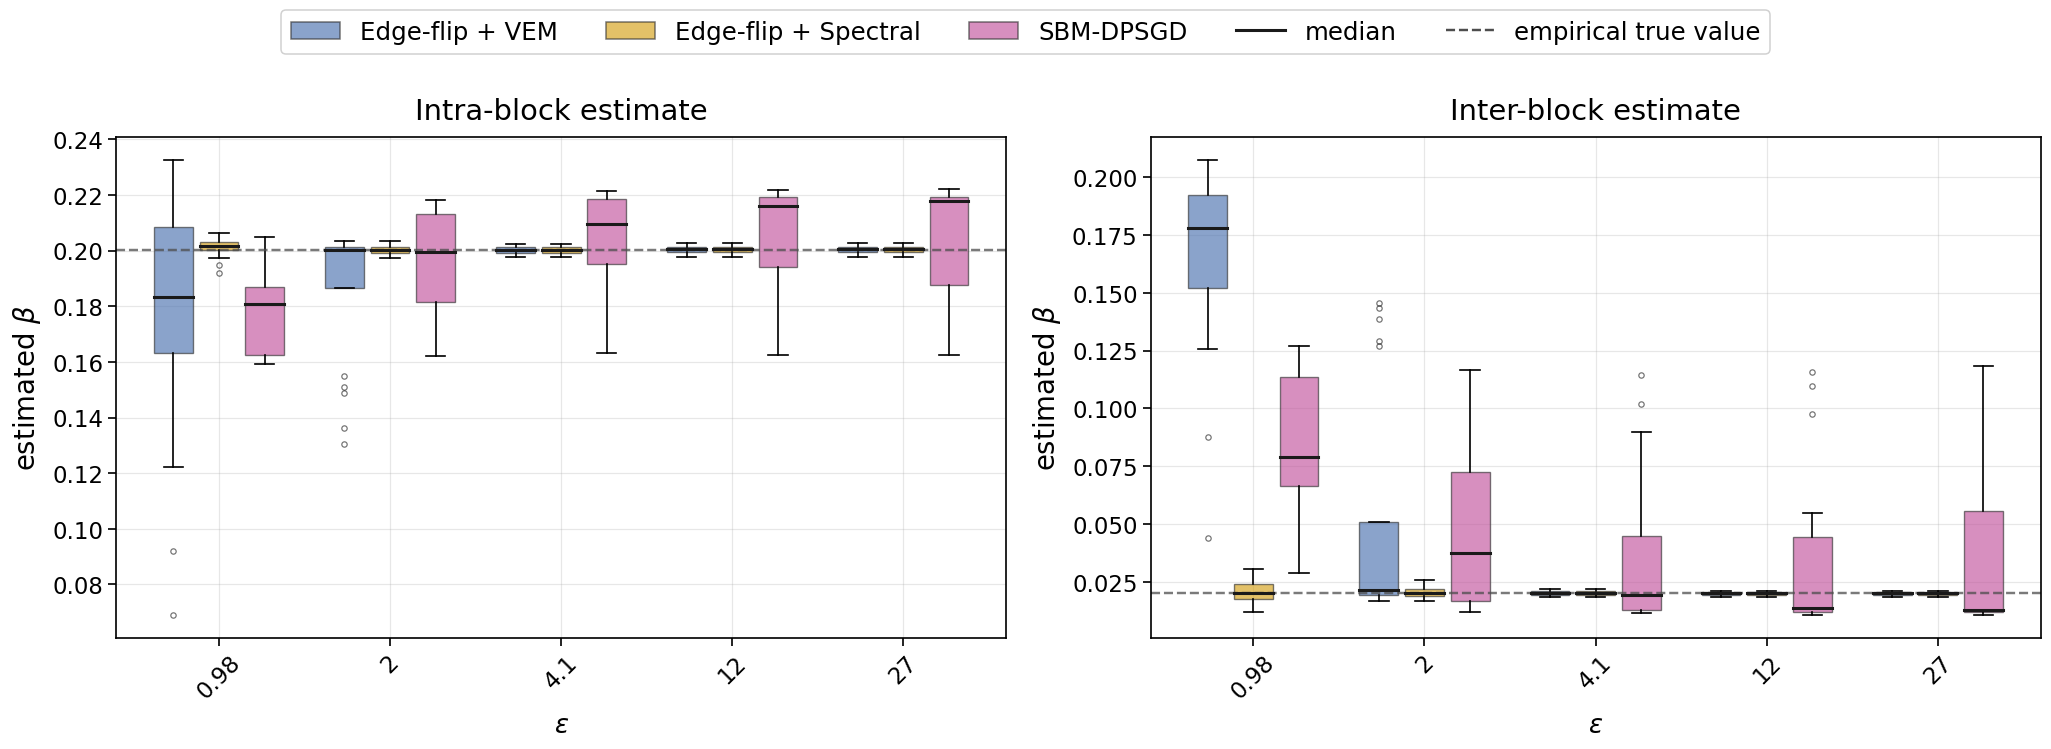

nominal (generative constants) vs empirical (what an SBM estimator targets):
  intra_00   nominal 0.2000   empirical 0.2000   ratio 1.0001
  inter_01   nominal 0.0200   empirical 0.0200   ratio 0.9988
  intra_11   nominal 0.2000   empirical 0.2005   ratio 1.0027

normalize_weights = True
ratio ~1.00 confirms the centering fix; ~0.64 would mean it is OFF and
scoring against nominal would show a ~35% error that is purely the
centering constant, not estimator bias.


In [7]:
# -- Boxplots of estimated beta vs epsilon -----------------------------------
apply_style()
df["intra_est"] = df[["beta_est_00", "beta_est_11"]].mean(axis=1)
df["intra_true"] = df[["beta_true_00", "beta_true_11"]].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=figsize(14.0, 5.0))
for ax, (est, tru, title) in zip(axes, [
        ("intra_est", "intra_true", "Intra-block estimate"),
        ("beta_est_01", "beta_true_01", "Inter-block estimate")]):
    grouped_boxplot(ax, df, est, methods=methods)
    reference_line(ax, df[tru].mean())
    ax.set_title(title, fontsize=19, pad=12)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"estimated $\beta$", fontsize=18)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
            Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
                   label="empirical true value")]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.03))
plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("figures/beta_dcsbm_n500.png", dpi=200, bbox_inches="tight")
plt.show()

# nominal vs empirical: the NORMALIZE_WEIGHTS check
nom = df[["beta_nominal_00", "beta_nominal_01", "beta_nominal_11"]].iloc[0]
emp = df[["beta_true_00", "beta_true_01", "beta_true_11"]].mean()
print("nominal (generative constants) vs empirical (what an SBM estimator targets):")
for a, b, name in zip(nom, emp, ["intra_00", "inter_01", "intra_11"]):
    print(f"  {name:<10} nominal {a:.4f}   empirical {b:.4f}   ratio {b/a:.4f}")
print(f"\nnormalize_weights = {df['normalize_weights'].iloc[0]}")
print("ratio ~1.00 confirms the centering fix; ~0.64 would mean it is OFF and")
print("scoring against nominal would show a ~35% error that is purely the")
print("centering constant, not estimator bias.")

## Degree heterogeneity

The knob this experiment exists to vary. Recorded per rep, never acted on.


In [8]:
# -- how heterogeneous were the drawn graphs? ---------------------------------
g = (df.groupby("rep")
       .agg(mean_degree=("mean_degree", "first"), degree_cv=("degree_cv", "first"),
            max_degree=("max_degree", "first"), min_degree=("min_degree", "first"),
            weight_mean=("weight_mean", "first"), weight_cv=("weight_cv", "first"))
       .round(3))
print(g.describe().round(3).to_string())
print(f"\ndc_sigma = {df['dc_sigma'].iloc[0]}")
print("weight_cv ~0.19 is the expected value at dc_sigma=0.25; weight_mean ~1.00")
print("confirms NORMALIZE_WEIGHTS.  degree_cv is the realized heterogeneity --")
print("compare it to a plain SBM, where it would be ~1/sqrt(mean degree).")
import math
print(f"  plain-SBM reference degree_cv at this density ~ "
      f"{1/math.sqrt(g['mean_degree'].mean()):.3f}   "
      f"observed {g['degree_cv'].mean():.3f}")

       mean_degree  degree_cv  max_degree  min_degree  weight_mean  weight_cv
count       20.000     20.000      20.000      20.000         20.0     20.000
mean        54.863      0.222     102.300      28.200          1.0      0.187
std          0.281      0.008       9.421       2.238          0.0      0.006
min         54.072      0.205      93.000      24.000          1.0      0.174
25%         54.750      0.217      95.750      27.000          1.0      0.184
50%         54.878      0.222     100.000      28.000          1.0      0.188
75%         55.025      0.226     105.500      29.000          1.0      0.190
max         55.288      0.241     126.000      33.000          1.0      0.200

dc_sigma = 0.25
weight_cv ~0.19 is the expected value at dc_sigma=0.25; weight_mean ~1.00
confirms NORMALIZE_WEIGHTS.  degree_cv is the realized heterogeneity --
compare it to a plain SBM, where it would be ~1/sqrt(mean degree).
  plain-SBM reference degree_cv at this density ~ 0.135   observed 0

## Compute cost (epochs)


methods with an epoch count: ['edge_flip_vem', 'sbm_dpsgd_all_noised']


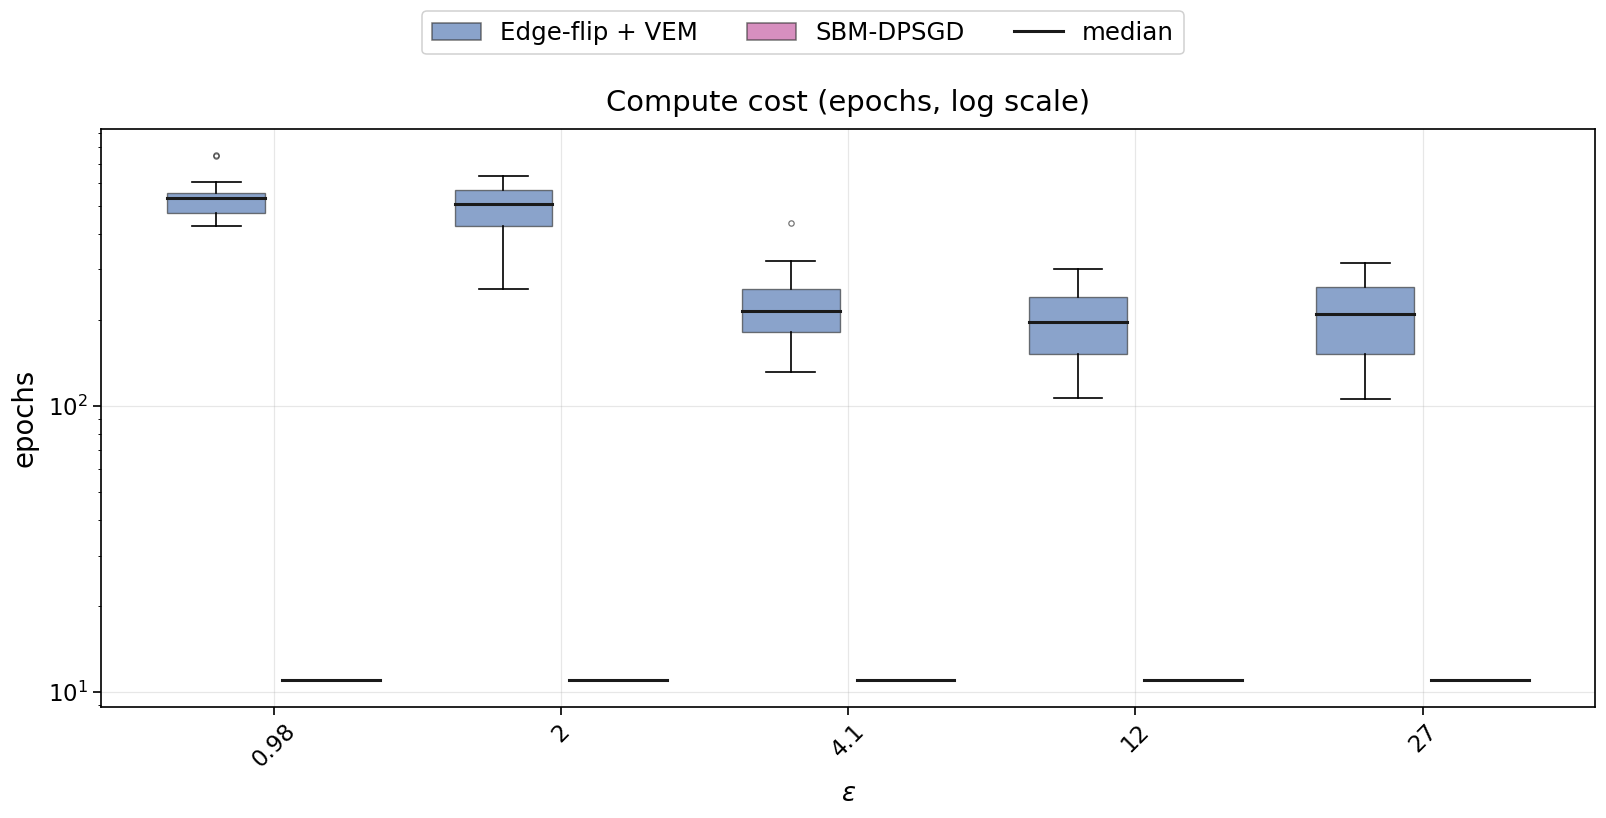

In [9]:
# -- Boxplots of # epochs vs epsilon -----------------------------------------
# NOT wall-clock comparable across methods: a VEM epoch is a dense O(N^2)
# matmul pass, an SBM-DPSGD epoch a sampled per-example autodiff pass.
# edge_flip_spectral is absent by construction -- no iterative epoch to count.
apply_style()
df_ep = df.dropna(subset=["epochs"])
methods_ep = order_methods(df_ep["method"].unique())
print("methods with an epoch count:", methods_ep)

fig, ax = plt.subplots(figsize=figsize(11.0, 5.5))
grouped_boxplot(ax, df_ep, "epochs", methods=methods_ep)
ax.set_yscale("log")
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel("epochs", fontsize=18)
ax.set_title("Compute cost (epochs, log scale)", fontsize=19, pad=12)
handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods_ep]
handles += [Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median")]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("figures/epochs_dcsbm_n500.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary table


In [10]:
summary = (df.groupby(["sigma", "epsilon", "method"])
             .agg(nmi_mean=("nmi", "mean"), nmi_std=("nmi", "std"),
                  nmi_min=("nmi", "min"), nmi_max=("nmi", "max"),
                  intra=("intra_est", "mean"), inter=("beta_est_01", "mean"),
                  n=("nmi", "size")).round(4))
print(summary.to_string())
print("\n\nmean NMI, methods side by side:")
print(df.pivot_table(index=["sigma", "epsilon"], columns="method",
                     values="nmi", aggfunc="mean").round(3).to_string())

                                      nmi_mean  nmi_std  nmi_min  nmi_max   intra   inter   n
sigma epsilon   method                                                                       
1.0   27.438851 edge_flip_spectral      1.0000   0.0000   1.0000   1.0000  0.2003  0.0200  20
                edge_flip_vem           1.0000   0.0000   1.0000   1.0000  0.2003  0.0200  20
                sbm_dpsgd_all_noised    0.7577   0.3884   0.0012   1.0000  0.2041  0.0378  20
2.0   11.728685 edge_flip_spectral      1.0000   0.0000   1.0000   1.0000  0.2003  0.0200  20
                edge_flip_vem           1.0000   0.0000   1.0000   1.0000  0.2003  0.0200  20
                sbm_dpsgd_all_noised    0.7949   0.3332   0.0009   1.0000  0.2052  0.0339  20
5.0   4.148451  edge_flip_spectral      1.0000   0.0000   1.0000   1.0000  0.2003  0.0201  20
                edge_flip_vem           1.0000   0.0000   1.0000   1.0000  0.2003  0.0201  20
                sbm_dpsgd_all_noised    0.7637   0.3264   0.